# IY025: Which telegraph-model parameters change as t_ac varies?

The IY014 t_ac variation dataset holds μ = 1000 and CV = 0.5 fixed while varying the autocorrelation time t_ac. But μ and CV are *summary statistics* — the underlying telegraph (two-state promoter) model has four rate parameters:

- **ρ (rho)** — transcription rate while the promoter is ON
- **d** — mRNA degradation rate
- **σ_b (sigma_b)** — rate of the OFF→ON transition ("burst-on")
- **σ_u (sigma_u)** — rate of the ON→OFF transition ("burst-off")

`find_tilda_parameters(mu, t_ac, cv)` solves for the unique (ρ, d, σ_b, σ_u) that reproduce a target (μ, t_ac, CV) triple, under the constraint σ_b + σ_u = `sigma_sum` = 1 (fixed by default). Since μ and CV are held fixed across the t_ac dataset but t_ac itself varies, **all four parameters must change** to compensate. This notebook quantifies exactly how.

In [1]:
import sys
sys.path.insert(0, '../../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams.update({
    'font.family':     'sans-serif',
    'axes.labelsize':  12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.titlesize':  14,
})
PALETTE = sns.color_palette('colorblind')

In [2]:
IY014_ROOT = Path('../EXP-26-IY014')
csv_path = IY014_ROOT / 'data_t_ac_variation' / 'IY014_simulation_t_ac_parameters_sobol.csv'

df = pd.read_csv(csv_path)
ok = (
    df['success'].astype(bool)
    & df['error_message'].isna()
    & (df['mean_rel_error_pct'] < 20)
    & (df['cv_rel_error_pct'] < 20)
    & (df['t_ac_rel_error_pct'] < 20)
)
df = df[ok].sort_values('t_ac_observed').reset_index(drop=True)
print(f'{len(df)} parameter sets (μ={df["mu_target"].iloc[0]:.0f}, CV={df["cv_target"].iloc[0]:.1f} fixed)')

# Confirm the sigma_sum constraint
sigma_sum = df['sigma_b'] + df['sigma_u']
print(f'σ_b + σ_u: mean={sigma_sum.mean():.6f}, std={sigma_sum.std():.2e}  (should be exactly 1.0)')

1012 parameter sets (μ=1000, CV=0.5 fixed)
σ_b + σ_u: mean=1.000000, std=1.09e-16  (should be exactly 1.0)


## 1. Raw telegraph-model parameters vs t_ac

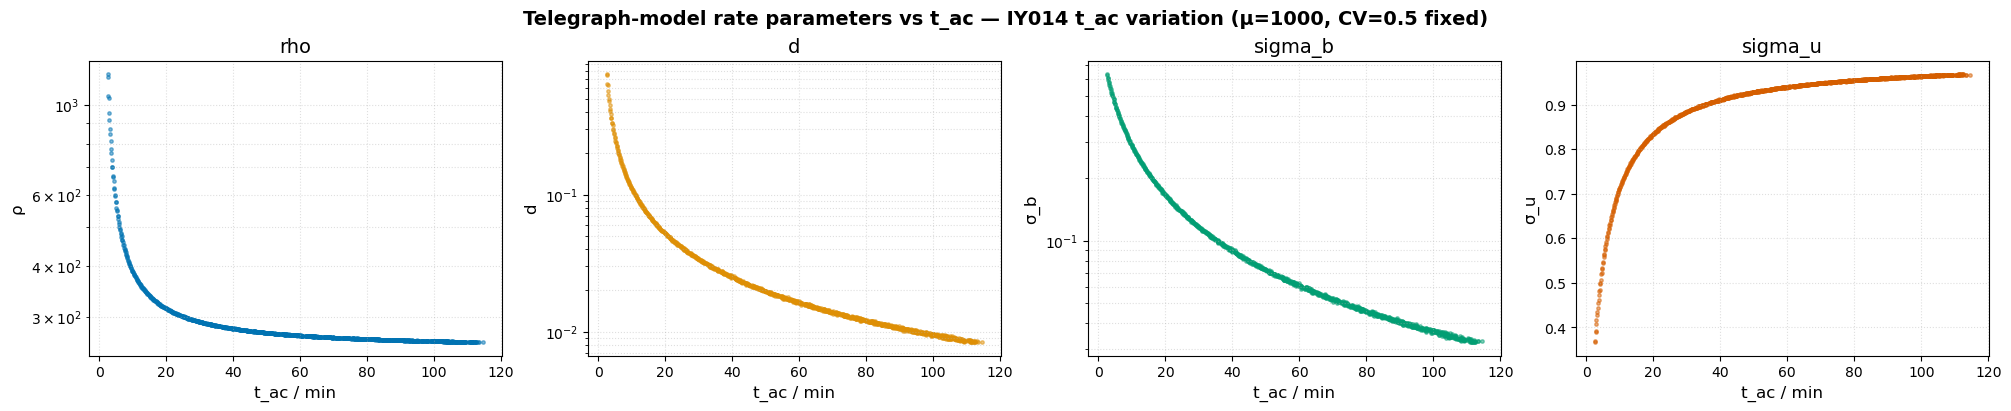

rho       : 259.5 → 1188  (×4.6 range)
d         : 0.008405 → 0.7517  (×89.4 range)
sigma_b   : 0.03239 → 0.6328  (×19.5 range)
sigma_u   : 0.3672 → 0.9676  (×2.6 range)


In [3]:
params = [
    ('rho',     'ρ',   PALETTE[0], 'log'),
    ('d',       'd',   PALETTE[1], 'log'),
    ('sigma_b', 'σ_b', PALETTE[2], 'log'),
    ('sigma_u', 'σ_u', PALETTE[3], 'linear'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4), constrained_layout=True)

for ax, (col, ylabel, color, yscale) in zip(axes, params):
    ax.scatter(df['t_ac_observed'], df[col], color=color, alpha=0.5, s=6, rasterized=True)
    ax.set_xlabel('t_ac / min', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_yscale(yscale)
    ax.set_title(col, fontsize=14)
    ax.grid(True, which='both', linestyle=':', alpha=0.4)

fig.suptitle(
    'Telegraph-model rate parameters vs t_ac — IY014 t_ac variation (μ=1000, CV=0.5 fixed)',
    fontsize=14, weight='bold',
)
plt.savefig('figures/IY025_tac_rate_parameters_vs_tac.png', dpi=150, bbox_inches='tight')
plt.show()

for col, _, _, _ in params:
    lo, hi = df[col].min(), df[col].max()
    print(f'{col:10s}: {lo:.4g} → {hi:.4g}  (×{hi/lo:.1f} range)')

## 2. Biological interpretation: ON/OFF dwell times and burst size

From the two-state promoter model, σ_b is the rate of *leaving* the OFF state (OFF→ON) and σ_u is the rate of *leaving* the ON state (ON→OFF). This gives:

- **Mean OFF dwell time** = 1/σ_b
- **Mean ON dwell time** = 1/σ_u
- **Fraction of time ON** (p_on) = σ_b / (σ_b + σ_u) = σ_b (since σ_b + σ_u = 1)
- **Burst size** (mRNA made per ON excursion, ignoring concurrent decay) ≈ ρ/d

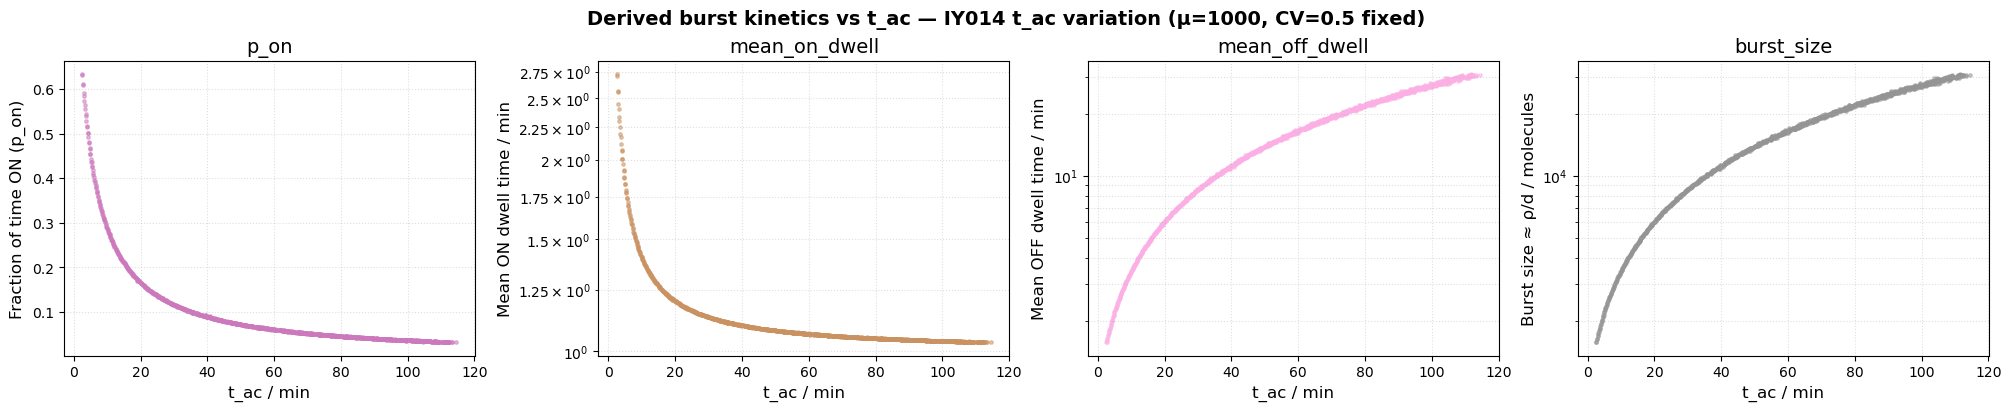

p_on           : 0.03239 → 0.6328
mean_on_dwell  : 1.033 → 2.723
mean_off_dwell : 1.58 → 30.88
burst_size     : 1580 → 3.088e+04


In [4]:
df['p_on']           = df['sigma_b'] / (df['sigma_b'] + df['sigma_u'])
df['mean_off_dwell']  = 1.0 / df['sigma_b']
df['mean_on_dwell']   = 1.0 / df['sigma_u']
df['burst_size']      = df['rho'] / df['d']

derived = [
    ('p_on',          'Fraction of time ON (p_on)',          PALETTE[4], 'linear'),
    ('mean_on_dwell',  'Mean ON dwell time / min',            PALETTE[5], 'log'),
    ('mean_off_dwell', 'Mean OFF dwell time / min',           PALETTE[6], 'log'),
    ('burst_size',     'Burst size ≈ ρ/d / molecules',        PALETTE[7], 'log'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4), constrained_layout=True)

for ax, (col, ylabel, color, yscale) in zip(axes, derived):
    ax.scatter(df['t_ac_observed'], df[col], color=color, alpha=0.5, s=6, rasterized=True)
    ax.set_xlabel('t_ac / min', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_yscale(yscale)
    ax.set_title(col, fontsize=14)
    ax.grid(True, which='both', linestyle=':', alpha=0.4)

fig.suptitle(
    'Derived burst kinetics vs t_ac — IY014 t_ac variation (μ=1000, CV=0.5 fixed)',
    fontsize=14, weight='bold',
)
plt.savefig('figures/IY025_tac_burst_kinetics_vs_tac.png', dpi=150, bbox_inches='tight')
plt.show()

for col, _, _, _ in derived:
    lo, hi = df[col].min(), df[col].max()
    print(f'{col:15s}: {lo:.4g} → {hi:.4g}')

## Summary

All four telegraph-model rate parameters change substantially as t_ac increases from ~2.5 to ~120 min, even though μ and CV are both held fixed:

| Parameter | Low t_ac (~2.5 min) | High t_ac (~120 min) | Direction |
|-----------|---------------------|------------------------|-----------|
| ρ (transcription rate) | ~1190 | ~260 | decreases ~4.6× |
| d (degradation rate)   | ~0.75 | ~0.008 | decreases ~90× (largest dynamic range) |
| σ_b (OFF→ON rate)      | ~0.63 | ~0.032 | decreases ~20× |
| σ_u (ON→OFF rate)      | ~0.37 | ~0.97 | increases ~2.6× |

**Biological picture**: to keep μ and CV fixed while increasing t_ac, the system shifts from *frequent, brief, moderate* bursts (low t_ac: p_on ≈ 0.6, short ON and OFF dwell times, fast mRNA turnover) to *rare, brief, intense* bursts (high t_ac: p_on ≈ 0.03, very long OFF periods, very slow mRNA degradation so each burst's mRNA lingers). This is exactly what produces the bimodal count distribution seen in the histogram analysis (`IY025_tac_mechanism_investigation.ipynb`): long OFF stretches near zero, punctuated by large but short-lived ON excursions, with slow decay (low d) keeping the mean at 1000 despite the gene being OFF ~97% of the time at high t_ac.